<a href="https://colab.research.google.com/github/luizkrawiec/estatistics/blob/main/teste_z_2_amostras_independentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Teste z para duas amostras independentes**

O número de amostras maior ou igual a 30

Necessita conhecimentos previo do desvio padrão

In [30]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels
from statsmodels.stats.diagnostic import lilliefors
from scipy.stats import levene
from statsmodels.stats.weightstats import ztest

In [4]:
enem_sp = pd.read_csv('/content/enem_2019_tratado.csv', sep=',', encoding='iso-8859-1')

In [5]:
enem_sp.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET
0,"1,90E+11",Santa Isabel,22,M,1,parda,1,1,não_respondeu,NaN,...,600.2,Inglês,1.0,160.0,200.0,180.0,200.0,200.0,940.0,Sim
1,"1,90E+11",São Paulo,17,F,1,parda,1,2,privada,15567761.0,...,731.8,Inglês,1.0,160.0,120.0,200.0,200.0,200.0,880.0,Não
2,"1,90E+11",São Bernardo do Campo,19,M,1,parda,1,2,pública,35904958.0,...,393.2,Espanhol,1.0,80.0,160.0,120.0,100.0,100.0,560.0,Sim
3,"1,90E+11",Embu-Guaçu,17,F,1,parda,1,2,pública,NaN,...,419.2,Inglês,1.0,120.0,120.0,120.0,120.0,80.0,560.0,Sim
4,"1,90E+11",Guarulhos,23,F,1,branca,1,1,não_respondeu,NaN,...,796.1,Inglês,1.0,160.0,200.0,180.0,180.0,160.0,880.0,Sim


## **Objetivo:**

Analisar a diferença entre as médias de mulheres e homens para a nota de um dos componentes de redação do colégio x

In [7]:
colegio_x = enem_sp.loc[enem_sp['CO_ESCOLA'] == 35017632.0]

In [8]:
colegio_x.shape

(41, 28)

In [9]:
colegio_x.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET
37,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,537.1,Inglês,1.0,120.0,40.0,40.0,120.0,20.0,340.0,Sim
44,"1,90E+11",Águas de Lindóia,17,F,1,parda,1,2,pública,35017632.0,...,451.9,Inglês,1.0,140.0,120.0,140.0,160.0,160.0,720.0,Não
52,"1,90E+11",Águas de Lindóia,17,F,1,branca,1,2,pública,35017632.0,...,506.4,Espanhol,1.0,120.0,120.0,120.0,120.0,80.0,560.0,Não
65,"1,90E+11",Águas de Lindóia,17,M,1,parda,1,2,pública,35017632.0,...,59.5,Inglês,1.0,120.0,120.0,120.0,120.0,40.0,520.0,Sim
79,"1,90E+11",Águas de Lindóia,18,F,1,branca,1,2,pública,35017632.0,...,510.6,Espanhol,1.0,120.0,120.0,120.0,140.0,140.0,640.0,Sim


In [10]:
colegiox_mulher = colegio_x.loc[colegio_x.SEXO == 'F']

In [11]:
colegiox_mulher.shape

(28, 28)

In [12]:
colegiox_homem = colegio_x.loc[colegio_x.SEXO == 'M']

In [13]:
colegiox_homem.shape

(13, 28)

In [14]:
colegiox_homem.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET
37,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,537.1,Inglês,1.0,120.0,40.0,40.0,120.0,20.0,340.0,Sim
65,"1,90E+11",Águas de Lindóia,17,M,1,parda,1,2,pública,35017632.0,...,59.5,Inglês,1.0,120.0,120.0,120.0,120.0,40.0,520.0,Sim
85,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,508.2,Espanhol,1.0,140.0,140.0,120.0,160.0,120.0,680.0,Sim
108151,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,705.3,Inglês,1.0,140.0,160.0,120.0,140.0,100.0,660.0,Sim
182519,"1,90E+11",Águas de Lindóia,17,M,1,parda,1,2,pública,35017632.0,...,480.9,Espanhol,1.0,100.0,120.0,100.0,100.0,100.0,520.0,Sim


# **Analisar a classificação das variáveis**

In [15]:
colegio_x.dtypes

NU_INSCRICAO                object
NO_MUNICIPIO_RESIDENCIA     object
IDADE                        int64
SEXO                        object
TP_ESTADO_CIVIL              int64
RACA                        object
TP_NACIONALIDADE             int64
TP_ST_CONCLUSAO              int64
ESCOLA                      object
CO_ESCOLA                  float64
NO_MUNICIPIO_ESC            object
TP_PRESENCA_CN               int64
TP_PRESENCA_CH               int64
TP_PRESENCA_LC               int64
TP_PRESENCA_MT               int64
NOTA_CN                    float64
NOTA_CH                    float64
NOTA_LC                    float64
NOTA_MT                    float64
TP_LINGUA                   object
TP_STATUS_REDACAO          float64
COMP1                      float64
COMP2                      float64
COMP3                      float64
COMP4                      float64
COMP5                      float64
NOTA_REDACAO               float64
INTERNET                    object
dtype: object

## **Analisar valores missing**

In [16]:
colegio_x.isnull().sum()

NU_INSCRICAO               0
NO_MUNICIPIO_RESIDENCIA    0
IDADE                      0
SEXO                       0
TP_ESTADO_CIVIL            0
RACA                       0
TP_NACIONALIDADE           0
TP_ST_CONCLUSAO            0
ESCOLA                     0
CO_ESCOLA                  0
NO_MUNICIPIO_ESC           0
TP_PRESENCA_CN             0
TP_PRESENCA_CH             0
TP_PRESENCA_LC             0
TP_PRESENCA_MT             0
NOTA_CN                    0
NOTA_CH                    0
NOTA_LC                    0
NOTA_MT                    0
TP_LINGUA                  0
TP_STATUS_REDACAO          0
COMP1                      0
COMP2                      0
COMP3                      0
COMP4                      0
COMP5                      0
NOTA_REDACAO               0
INTERNET                   0
dtype: int64

## **Analisar outliers**

In [20]:
grafico = px.box(colegiox_mulher, y='COMP5')
grafico.show()

In [21]:
grafico = px.box(colegiox_homem, y='COMP5')
grafico.show()

## **Analisar Normalidade**

Critérios:

Nível de Significância de 0,05 ou 5% (MAIS UTILIZADO)

Quando p > 0,05 (distribuição normal).

In [22]:
#teste Shapiro- Wilk
stats.shapiro(colegiox_mulher['COMP5'])

ShapiroResult(statistic=0.9521203637123108, pvalue=0.2238943725824356)

In [23]:
#teste Shapiro- Wilk
stats.shapiro(colegiox_homem['COMP5'])

ShapiroResult(statistic=0.942307710647583, pvalue=0.48747217655181885)

<Axes: xlabel='COMP5', ylabel='Probability'>

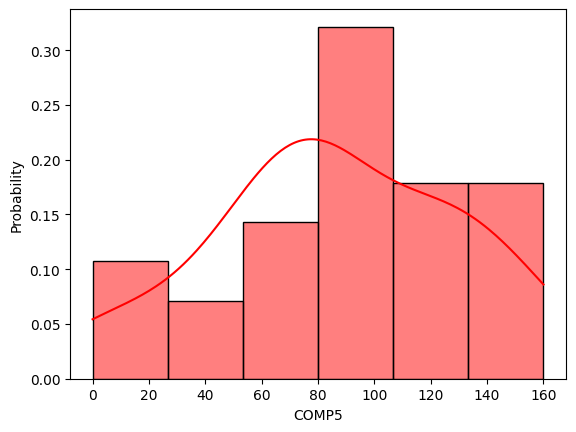

In [24]:
sns.histplot(colegiox_mulher, x='COMP5', bins=6, color='red', kde=True, stat='probability')

<Axes: xlabel='COMP5', ylabel='Probability'>

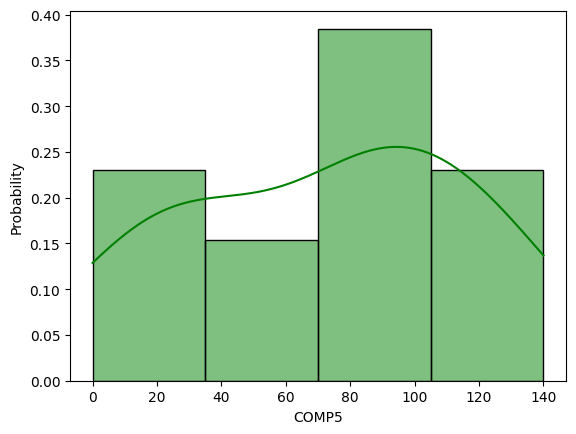

In [26]:
sns.histplot(colegiox_homem, x='COMP5', bins=4, color='green', kde=True, stat='probability')

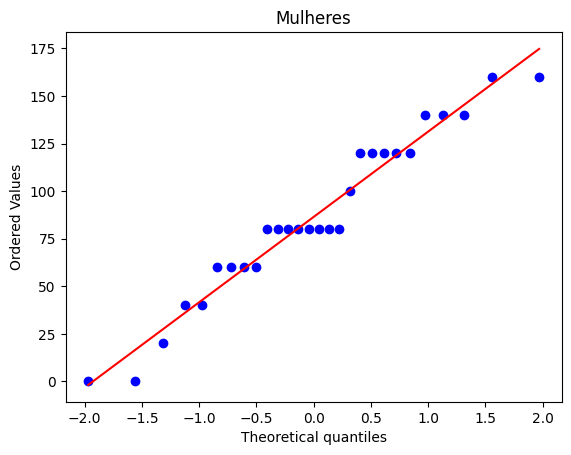

In [27]:
stats.probplot(colegiox_mulher['COMP5'], plot=plt,dist='norm')
plt.title('Mulheres')
plt.show()

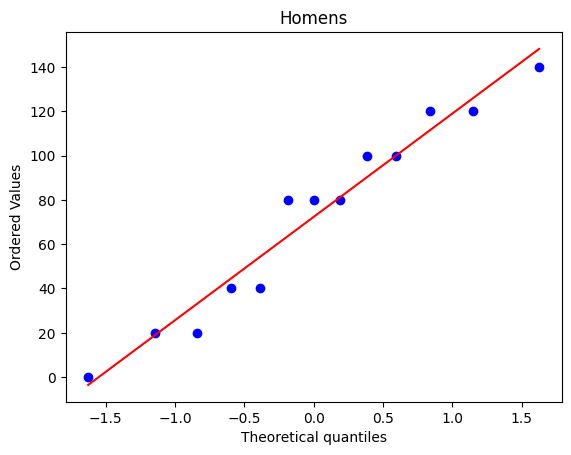

In [28]:
stats.probplot(colegiox_homem['COMP5'], plot=plt,dist='norm')
plt.title('Homens')
plt.show()

## **Homogenidade das variâncias(homocedasticidade)**

variabiliade dos erros constantes.

Ho = variâncias homogêneas: p>0.05

Ha = variâncias não homogênas: p<= 0.05

In [29]:
stat, p = levene(colegiox_mulher['COMP5'], colegiox_homem['COMP5'], center='mean')
print('Estatística de teste{}'.format(stat.round(2)))
print('p-valor:{}'.format(p.round(10)))

Estatística de teste0.07
p-valor:0.7899416696


# **Teste Z para duas amostras**

Comparação das médias das notas do componente 5 da redação entre homens e mulheres do colégio Y.

Ho =  Não há diferença entre as médias dos componentes: p>0.05

Ha =  Há diferença entre as médias dos componentes: p<0.05

In [33]:
stat, p = ztest(colegiox_mulher['COMP5'], colegiox_homem['COMP5'])
print('Estatística de teste{}'.format(stat.round(2)))
print('p-valor:{}'.format(p.round(10)))

Estatística de teste0.96
p-valor:0.339491895


In [35]:
colegiox_mulher.COMP5.describe()

count     28.000000
mean      86.428571
std       43.903453
min        0.000000
25%       60.000000
50%       80.000000
75%      120.000000
max      160.000000
Name: COMP5, dtype: float64

In [36]:
colegiox_homem.COMP5.describe()

count     13.000000
mean      72.307692
std       44.376016
min        0.000000
25%       40.000000
50%       80.000000
75%      100.000000
max      140.000000
Name: COMP5, dtype: float64

## **Intrepretação**

teste estatístico:0,96

p_valor = 0,039

Conclusão: Estatisticamente, com intervalo de confiança de 95%, não se pode concluir que a média do componente 5 de redação do colegio X seja diferente entre homens e mulheres